In [38]:
from deap import tools, creator, base, algorithms, benchmarks
from math import factorial
from numpy import random
from meamt_core import generate_zdt4_front_true, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "zdt4"
NOBJ = 2
K = 10
NDIM = 10
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_zdt4_front_true(10000, NDIM)

In [ ]:
NGEN = 600
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)
H = len(ref_points)
MU = H + (4 - H % 4) if H % 4 != 0 else H


In [40]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.zdt4)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [41]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        hv_val = hypervolume(pop, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [42]:
pop, logbook = main()

gen	evals	std                      	min                            	avg                      	max                        	hypervolume	igd_plus
0  	400  	[ 0.28767229 20.4472703 ]	[5.78129505e-03 3.43295830e+01]	[ 0.49439396 86.03355904]	[  0.99990184 140.20601886]	           	        
1  	400  	[ 0.26526761 19.93645815]	[3.11204191e-03 2.58176356e+01]	[ 0.3454803 75.561298 ]  	[  0.9969447  134.57312393]	0          	25.4826 
2  	400  	[ 0.2524906  20.87524395]	[3.11204191e-03 1.56901253e+01]	[ 0.27069294 68.15153459]	[  0.99871039 135.86475479]	0          	15.3544 
3  	400  	[ 0.24596512 21.78621872]	[1.94593838e-04 1.53102839e+01]	[ 0.22917876 61.07024348]	[  0.99943502 135.86475479]	0          	14.9783 
4  	400  	[ 0.21447742 22.42986788]	[1.94593838e-04 1.13311731e+01]	[ 0.18443951 55.30320694]	[  0.88512132 126.61465281]	0          	10.9955 
5  	400  	[ 0.17656006 21.04136973]	[4.32971733e-05 1.13311731e+01]	[ 0.13921023 49.5805345 ]	[  0.87948868 131.92860148]	0          	10.9955 

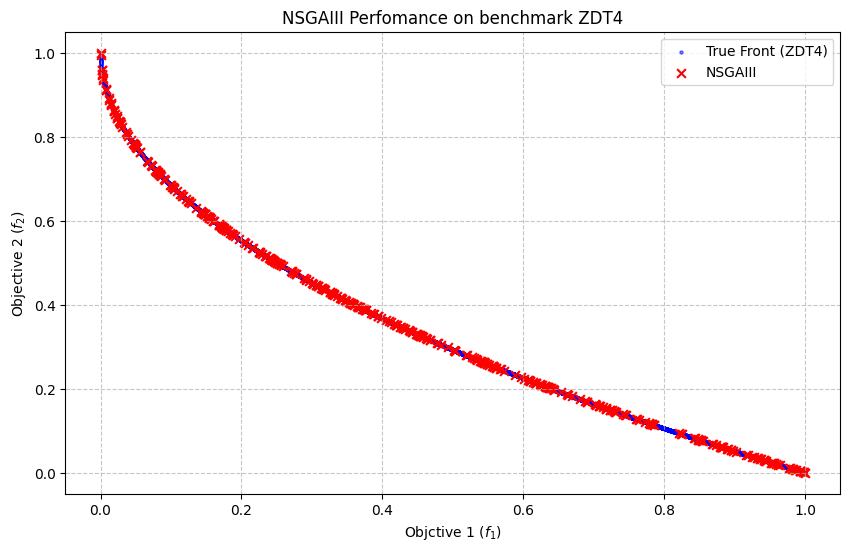

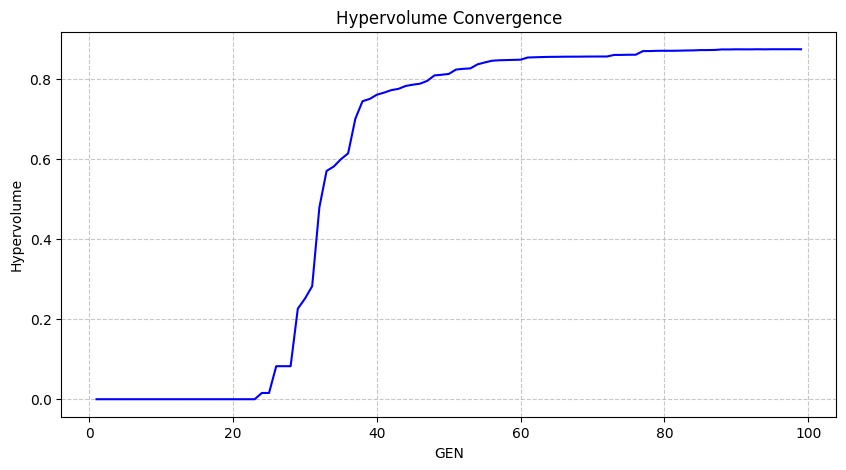

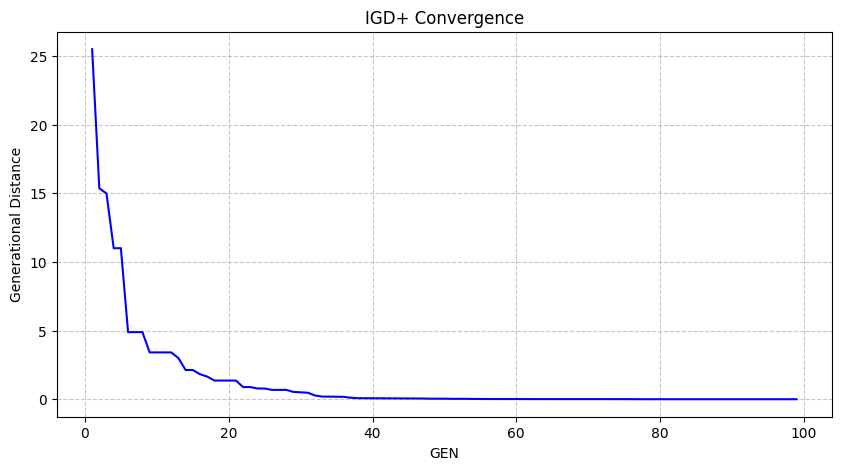

In [43]:
import matplotlib.pyplot as plt
f1_approx = [ind.fitness.values[0] for ind in pop]
f2_approx = [ind.fitness.values[1] for ind in pop]

f1_true = [linha[0] for linha in pareto_real]
f2_true = [linha[1] for linha in pareto_real]


plt.figure(figsize=(10, 6))


plt.scatter(f1_true, f2_true, color='blue', s=5, alpha=0.5, label='True Front (ZDT4)')


plt.scatter(f1_approx, f2_approx, color='red', marker='x', s=40, label='NSGAIII')

plt.title("NSGAIII Perfomance on benchmark ZDT4")
plt.xlabel("Objctive 1 ($f_1$)")
plt.ylabel("Objective 2 ($f_2$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Exibe o gráfico
plt.show()
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()